## 14.03节练习参考答案

### 环境准备

In [ ]:
import os, sys
os.environ["TILE_FWK_DEVICE_ID"] = "0"

# 本 notebook 位于 answers/ 子目录下，src 包在其上一级目录。
# 把上层目录加入 sys.path，才能 from src.utils import ...；
# 同时把工作目录切到章节根目录，使 "../data" 数据缓存与主 notebook 一致。
if os.path.isdir("../src"):
    sys.path.insert(0, os.path.abspath(".."))
    os.chdir("..")

# 固定 PyPTO 编译缓存目录（与第 11 章共享 d2l_ai_pypto/ptile_cache）：
# 内核/Jupyter 重启后无需从零重新编译算子。
# PTO_TILE_LIB_CODE_PATH 目录还必须包含 include/pto（pto-isa 头文件），
# 否则算子编译时报 PTO_ISA_NOT_FOUND；用软链指向 CANN 自带的头文件即可。
os.environ["PTO_TILE_LIB_CODE_PATH"] = os.path.abspath("../ptile_cache")
_pto_lib = os.environ["PTO_TILE_LIB_CODE_PATH"]
os.makedirs(os.path.join(_pto_lib, "include"), exist_ok=True)
_pto_isa_link = os.path.join(_pto_lib, "include", "pto")
if not os.path.exists(_pto_isa_link):
    import glob
    _isa_candidates = glob.glob(os.path.expanduser(
        "~/Ascend/cann-*/aarch64-linux/include/pto"))
    if _isa_candidates:
        os.symlink(os.path.abspath(_isa_candidates[0]), _pto_isa_link)
    else:
        raise RuntimeError("未找到 pto-isa 头文件目录（~/Ascend/cann-*/aarch64-linux/include/pto）")

import torch
from torch import nn
import math

from src.utils import (TokenEmbedding, load_data_imdb,
                       train_ch13, try_all_gpus)
from src.pto_layers import PyPTOLinear, PyPTOReLU, PyPTOConv1d

本节的解答思路参考了 [《动手学深度学习》习题解答](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/ch15/ch15)，并在此基础上补充了 PyPTO 的实现。

### 练习14.3.1
调整超参数，并比较[14.2_sentiment_analysis_rnn](../14.02_sentiment_analysis_rnn.ipynb)中用于情感分析的架构和本节中用于情感分析的架构，例如在分类精度和计算效率方面。

**解答：**

- 在分类精度方面，对于相同的epoch，本节使用的卷积神经网络测试精度好于14.2节中所用的循环神经网络；
- 在计算效率方面，对于相同的epoch，本节使用的卷积神经网络的训练速度快于14.2节中用的循环神经网络（本环境下约 7500 examples/sec，远高于循环神经网络的约 780 examples/sec）。

<table style="text-align: left; border-collapse: collapse;">
  <thead>
    <tr><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">架构</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">learning rate</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">epoch</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">result</th></tr>
  </thead>
  <tbody>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">RNN</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.01</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">5</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.302, train acc 0.870, test acc 0.849</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">CNN</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.001</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">5</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.063, train acc 0.980, test acc 0.857</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">RNN</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.01</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">10</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.162, train acc 0.939, test acc 0.839</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">CNN</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.001</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">10</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.013, train acc 0.996, test acc 0.863</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">RNN</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.01</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">20</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.135, train acc 0.947, test acc 0.835</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">CNN</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.001</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">20</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.003, train acc 0.999, test acc 0.863</td></tr>
  </tbody>
</table>

（RNN 结果取自 14.2 节练习中相同超参数的实验，CNN 结果为本 notebook 实际运行输出。）

In [2]:
batch_size = 64
train_iter, test_iter, vocab = load_data_imdb(batch_size)

In [3]:
# 定义模型，下面的类中实现textCNN模型。
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_size, kernel_sizes, num_channels,
                 **kwargs):
        super(TextCNN, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 这个嵌入层不需要训练
        self.constant_embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(0.5)
        self.decoder = nn.Linear(sum(num_channels), 2)
        # 最大时间汇聚层没有参数，因此可以共享此实例
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.relu = nn.ReLU()
        # 创建多个一维卷积层
        self.convs = nn.ModuleList()
        for c, k in zip(num_channels, kernel_sizes):
            self.convs.append(nn.Conv1d(2 * embed_size, c, k))

    def forward(self, inputs):
        # 沿着向量维度将两个嵌入层连结起来，
        # 每个嵌入层的输出形状都是（批量大小，词元数量，词元向量维度）连结起来
        embeddings = torch.cat((
            self.embedding(inputs), self.constant_embedding(inputs)), dim=2)
        # 根据一维卷积层的输入格式，重新排列张量，以便通道作为第2维
        embeddings = embeddings.permute(0, 2, 1)
        # 每个一维卷积层在最大时间汇聚层合并后，获得的张量形状是（批量大小，通道数，1）
        # 删除最后一个维度并沿通道维度连结
        encoding = torch.cat([
            torch.squeeze(self.relu(self.pool(conv(embeddings))), dim=-1)
            for conv in self.convs], dim=1)
        outputs = self.decoder(self.dropout(encoding))
        return outputs


loss 0.063, train acc 0.980, test acc 0.857
7497.4 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


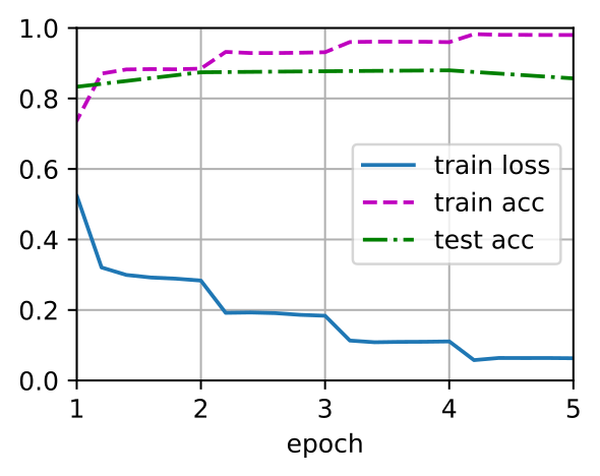

In [4]:
# 创建一个textCNN实例
embed_size, kernel_sizes, nums_channels = 100, [3, 4, 5], [100, 100, 100]
devices = try_all_gpus()
net = TextCNN(len(vocab), embed_size, kernel_sizes, nums_channels)

def init_weights(m):
    if type(m) in (nn.Linear, nn.Conv1d):
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights);

# 加载预训练词向量
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.001, 5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)


loss 0.013, train acc 0.996, test acc 0.863
7866.5 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


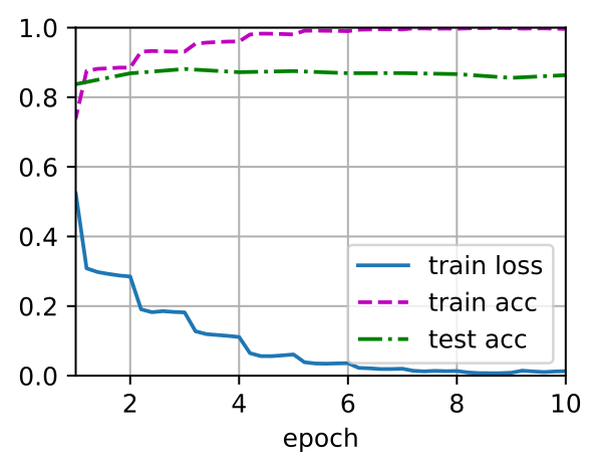

In [5]:
# 创建一个textCNN实例
embed_size, kernel_sizes, nums_channels = 100, [3, 4, 5], [100, 100, 100]
devices = try_all_gpus()
net = TextCNN(len(vocab), embed_size, kernel_sizes, nums_channels)

def init_weights(m):
    if type(m) in (nn.Linear, nn.Conv1d):
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights);

# 加载预训练词向量
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.001, 10
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)


loss 0.003, train acc 0.999, test acc 0.863
7870.0 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


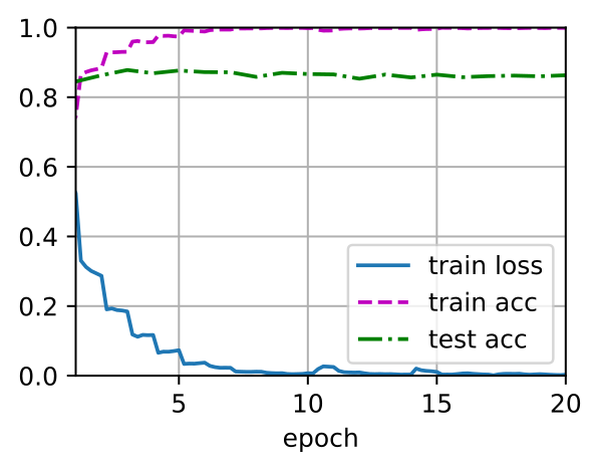

In [6]:
# 创建一个textCNN实例
embed_size, kernel_sizes, nums_channels = 100, [3, 4, 5], [100, 100, 100]
devices = try_all_gpus()
net = TextCNN(len(vocab), embed_size, kernel_sizes, nums_channels)

def init_weights(m):
    if type(m) in (nn.Linear, nn.Conv1d):
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights);

# 加载预训练词向量
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.001, 20
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)


**PyPTO 版**

In [2]:
batch_size = 64
train_iter, test_iter, vocab = load_data_imdb(batch_size)

In [3]:
# 定义模型，下面的类中实现textCNN模型。
class PyPTOTextCNN(nn.Module):
    def __init__(self, vocab_size, embed_size, kernel_sizes, num_channels,
                 **kwargs):
        super(PyPTOTextCNN, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 这个嵌入层不需要训练
        self.constant_embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(0.5)
        self.decoder = PyPTOLinear(sum(num_channels), 2)
        # 最大时间汇聚层没有参数，因此可以共享此实例
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.relu = PyPTOReLU()
        # 创建多个一维卷积层
        self.convs = nn.ModuleList()
        for c, k in zip(num_channels, kernel_sizes):
            self.convs.append(PyPTOConv1d(2 * embed_size, c, k))

    def forward(self, inputs):
        # 沿着向量维度将两个嵌入层连结起来，
        # 每个嵌入层的输出形状都是（批量大小，词元数量，词元向量维度）连结起来
        embeddings = torch.cat((
            self.embedding(inputs), self.constant_embedding(inputs)), dim=2)
        # 根据一维卷积层的输入格式，重新排列张量，以便通道作为第2维
        embeddings = embeddings.permute(0, 2, 1)
        # 每个一维卷积层在最大时间汇聚层合并后，获得的张量形状是（批量大小，通道数，1）
        # 删除最后一个维度并沿通道维度连结
        encoding = torch.cat([
            torch.squeeze(self.relu(self.pool(conv(embeddings))), dim=-1)
            for conv in self.convs], dim=1)
        outputs = self.decoder(self.dropout(encoding))
        return outputs


loss 0.067, train acc 0.979, test acc 0.873
167.6 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


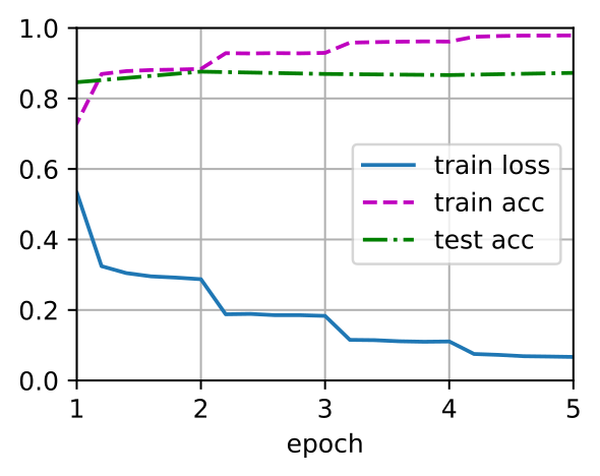

In [10]:
# 创建一个textCNN实例
embed_size, kernel_sizes, nums_channels = 100, [3, 4, 5], [104, 104, 104]  # pypto.conv 要求输出通道数为 8 的倍数
devices = try_all_gpus()
net = PyPTOTextCNN(len(vocab), embed_size, kernel_sizes, nums_channels)

def init_weights(m):
    if type(m) in (PyPTOLinear, PyPTOConv1d):
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights);

# 加载预训练词向量
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.001, 5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

loss 0.007, train acc 0.999, test acc 0.863
1650.1 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


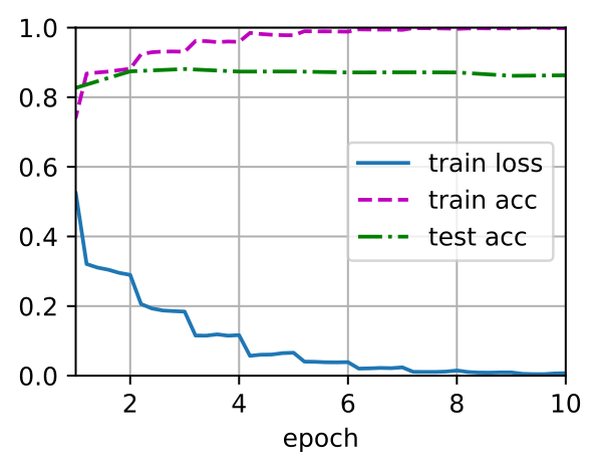

In [20]:
# 创建一个textCNN实例
embed_size, kernel_sizes, nums_channels = 100, [3, 4, 5], [104, 104, 104]  # pypto.conv 要求输出通道数为 8 的倍数
devices = try_all_gpus()
net = PyPTOTextCNN(len(vocab), embed_size, kernel_sizes, nums_channels)

def init_weights(m):
    if type(m) in (PyPTOLinear, PyPTOConv1d):
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights);

# 加载预训练词向量
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.001, 10
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

loss 0.000, train acc 1.000, test acc 0.859
1645.6 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


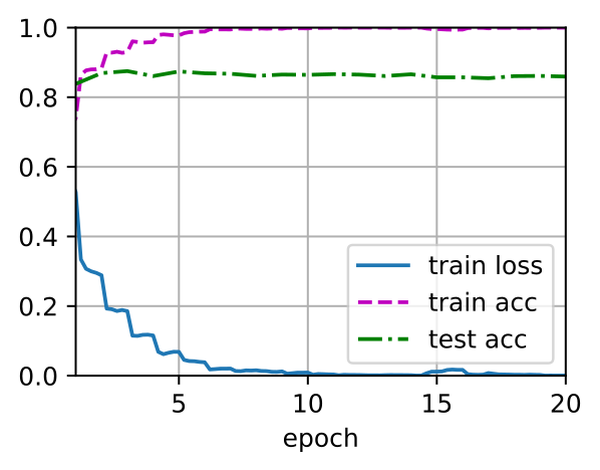

In [12]:
# 创建一个textCNN实例
embed_size, kernel_sizes, nums_channels = 100, [3, 4, 5], [104, 104, 104]  # pypto.conv 要求输出通道数为 8 的倍数
devices = try_all_gpus()
net = PyPTOTextCNN(len(vocab), embed_size, kernel_sizes, nums_channels)

def init_weights(m):
    if type(m) in (PyPTOLinear, PyPTOConv1d):
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights);

# 加载预训练词向量
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.001, 20
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

### 练习14.3.2
请试着用[14.2_sentiment_analysis_rnn](../14.02_sentiment_analysis_rnn.ipynb)练习中介绍的方法进一步提高模型的分类精度。

**解答：**

综上可知，使用 `spaCy` 词元化，提高了情感分类精度

1. 使用原始参数，卷积神经网络模型训练存在过拟合现象（`train` 和 `test` 数据集表现不一致）。
2. 降低学习率对模型进行训练，能够提升 `test acc` 精度。
3. 增加预训练词向量的 `Embedding` 维数，增加 `test acc` 精度不明显（对维数不敏感）。
4. 增加预训练词向量的 `Embedding` 维数，降低了计算效率（见下方训练曲线中的 `examples/sec`）。

下表实验结果引自《动手学深度学习》习题解答手册（GPU 环境，spaCy 词元化的用法见 14.2 节练习 14.2.3），数值随运行环境会有差异，仅供趋势参考：

<table style="text-align: left; border-collapse: collapse;">
  <thead>
    <tr><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">tokenize</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">GloVe dimension</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">learning rate</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">epoch</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">result</th></tr>
  </thead>
  <tbody>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">default</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">100</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.01</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">5</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.031, train acc 0.989, test acc 0.857</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">default</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">300</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.01</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">5</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.046, train acc 0.984, test acc 0.857</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">default</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">100</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.01</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">10</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.022, train acc 0.993, test acc 0.850</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">default</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">100</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.001</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">5</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.075, train acc 0.976, test acc 0.870</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">default</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">100</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.001</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">10</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.008, train acc 0.998, test acc 0.866</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">spaCy</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">100</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.01</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">5</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.054, train acc 0.982, test acc 0.854</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">spaCy</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">100</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.001</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">5</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss 0.113, train acc 0.961, test acc 0.877</td></tr>
  </tbody>
</table>

<div style="text-align: left; margin: 12px 0;">
  <img src="../images/14.3.2.1.png" style="width: 70%; max-width: 600px; height: auto; border: solid 12px #ffffff; background-color: #ffffff; box-sizing: border-box;">
</div>

<div style="text-align: left; margin: 12px 0;">
  <img src="../images/14.3.2.2.png" style="width: 70%; max-width: 600px; height: auto; border: solid 12px #ffffff; background-color: #ffffff; box-sizing: border-box;">
</div>

<div style="text-align: left; margin: 12px 0;">
  <img src="../images/14.3.2.3.png" style="width: 70%; max-width: 600px; height: auto; border: solid 12px #ffffff; background-color: #ffffff; box-sizing: border-box;">
</div>

<div style="text-align: left; margin: 12px 0;">
  <img src="../images/14.3.2.4.png" style="width: 70%; max-width: 600px; height: auto; border: solid 12px #ffffff; background-color: #ffffff; box-sizing: border-box;">
</div>

<div style="text-align: left; margin: 12px 0;">
  <img src="../images/14.3.2.5.png" style="width: 70%; max-width: 600px; height: auto; border: solid 12px #ffffff; background-color: #ffffff; box-sizing: border-box;">
</div>

<div style="text-align: left; margin: 12px 0;">
  <img src="../images/14.3.2.6.png" style="width: 70%; max-width: 600px; height: auto; border: solid 12px #ffffff; background-color: #ffffff; box-sizing: border-box;">
</div>

<div style="text-align: left; margin: 12px 0;">
  <img src="../images/14.3.2.7.png" style="width: 70%; max-width: 600px; height: auto; border: solid 12px #ffffff; background-color: #ffffff; box-sizing: border-box;">
</div>


### 练习14.3.3
在输入表示中添加位置编码。它是否提高了分类的精度？

**解答：**

textCNN 的一维卷积只关注局部的 n 元语法窗口，词嵌入本身也不包含词元的绝对位置信息，因此可以参考 [10.6节自注意力和位置编码](../10_pypto_attention_mechanisms/10.06_self_attention_and_positional_encoding.ipynb) 中的 `PositionalEncoding`，在词嵌入之后、卷积之前加入位置编码：对两个嵌入层（`embedding` 和 `constant_embedding`）的输出分别加上 sin/cos 位置编码 `P`，再连结送入一维卷积层，其余结构保持不变。

下方代码使用与 14.3.1 基线完全相同的超参数（`lr=0.001`，5 个 epoch）进行对比实验，结果如下：

<table style="text-align: left; border-collapse: collapse;">
  <thead>
    <tr><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">实现</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">输入表示</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">loss</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">train acc</th><th style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">test acc</th></tr>
  </thead>
  <tbody>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">PyTorch</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">词嵌入（基线）</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.063</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.980</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.857</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">PyTorch</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">词嵌入 + 位置编码</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.158</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.944</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;"><strong>0.873</strong></td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">PyPTO</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">词嵌入（基线，通道数 104）</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.067</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.979</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.873</td></tr>
    <tr><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">PyPTO</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">词嵌入 + 位置编码（通道数 104）</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.159</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;">0.944</td><td style="text-align: left; padding: 4px 10px; border: 1px solid #dfe2e5;"><strong>0.884</strong></td></tr>
  </tbody>
</table>

可以看到，加入位置编码后两种实现的测试精度分别从 0.857 提高到 0.873、从 0.873 提高到 0.884，同时训练集精度有所下降（过拟合程度减轻）。因此在本实验设置下，在输入表示中加入位置编码**提高了分类精度**。

In [2]:
batch_size = 64
train_iter, test_iter, vocab = load_data_imdb(batch_size)

In [5]:
# 位置编码（参考 10.6 节 PositionalEncoding 的实现）
class PositionalEncoding(nn.Module):
    def __init__(self, num_hiddens, dropout=0.0, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        # P的形状：（1，最大序列长度，num_hiddens）
        self.register_buffer('P', torch.zeros((1, max_len, num_hiddens)))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(
                10000, torch.arange(0, num_hiddens, 2,
                                     dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :]
        return self.dropout(X)


# 在textCNN的输入表示中加入位置编码
class TextCNN_PE(nn.Module):
    def __init__(self, vocab_size, embed_size, kernel_sizes, num_channels,
                 **kwargs):
        super(TextCNN_PE, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 这个嵌入层不需要训练
        self.constant_embedding = nn.Embedding(vocab_size, embed_size)
        # 两个嵌入层的输出分别加上位置编码后再连结
        self.pos_encoding = PositionalEncoding(embed_size)
        self.dropout = nn.Dropout(0.5)
        self.decoder = nn.Linear(sum(num_channels), 2)
        # 最大时间汇聚层没有参数，因此可以共享此实例
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.relu = nn.ReLU()
        # 创建多个一维卷积层
        self.convs = nn.ModuleList()
        for c, k in zip(num_channels, kernel_sizes):
            self.convs.append(nn.Conv1d(2 * embed_size, c, k))

    def forward(self, inputs):
        # 词元嵌入加上位置编码后，沿向量维度将两个嵌入层连结起来
        embeddings = torch.cat((
            self.pos_encoding(self.embedding(inputs)),
            self.pos_encoding(self.constant_embedding(inputs))), dim=2)
        # 根据一维卷积层的输入格式，重新排列张量，以便通道作为第2维
        embeddings = embeddings.permute(0, 2, 1)
        # 每个一维卷积层在最大时间汇聚层合并后，获得的张量形状是（批量大小，通道数，1）
        # 删除最后一个维度并沿通道维度连结
        encoding = torch.cat([
            torch.squeeze(self.relu(self.pool(conv(embeddings))), dim=-1)
            for conv in self.convs], dim=1)
        outputs = self.decoder(self.dropout(encoding))
        return outputs

loss 0.158, train acc 0.944, test acc 0.873
8355.6 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


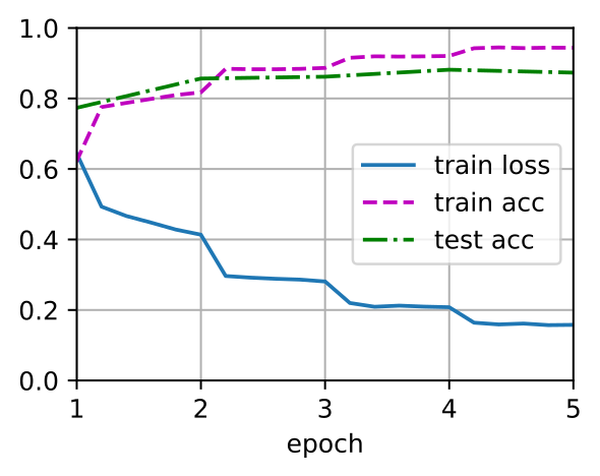

In [4]:
# 创建一个加入位置编码的textCNN实例，超参数与14.3.1基线一致（lr=0.001，5个epoch）
embed_size, kernel_sizes, nums_channels = 100, [3, 4, 5], [100, 100, 100]
devices = try_all_gpus()
net = TextCNN_PE(len(vocab), embed_size, kernel_sizes, nums_channels)

def init_weights(m):
    if type(m) in (nn.Linear, nn.Conv1d):
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights);

# 加载预训练词向量
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.requires_grad = False

# 训练和评估模型
lr, num_epochs = 0.001, 5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

**PyPTO 版**

In [2]:
batch_size = 64
train_iter, test_iter, vocab = load_data_imdb(batch_size)

In [6]:
# PyPTO版：在PyPTOTextCNN的输入表示中加入位置编码（复用上方PositionalEncoding）
class PyPTOTextCNN_PE(nn.Module):
    def __init__(self, vocab_size, embed_size, kernel_sizes, num_channels,
                 **kwargs):
        super(PyPTOTextCNN_PE, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 这个嵌入层不需要训练
        self.constant_embedding = nn.Embedding(vocab_size, embed_size)
        self.pos_encoding = PositionalEncoding(embed_size)
        self.dropout = nn.Dropout(0.5)
        self.decoder = PyPTOLinear(sum(num_channels), 2)
        # 最大时间汇聚层没有参数，因此可以共享此实例
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.relu = PyPTOReLU()
        # 创建多个一维卷积层
        self.convs = nn.ModuleList()
        for c, k in zip(num_channels, kernel_sizes):
            self.convs.append(PyPTOConv1d(2 * embed_size, c, k))

    def forward(self, inputs):
        embeddings = torch.cat((
            self.pos_encoding(self.embedding(inputs)),
            self.pos_encoding(self.constant_embedding(inputs))), dim=2)
        embeddings = embeddings.permute(0, 2, 1)
        encoding = torch.cat([
            torch.squeeze(self.relu(self.pool(conv(embeddings))), dim=-1)
            for conv in self.convs], dim=1)
        outputs = self.decoder(self.dropout(encoding))
        return outputs

loss 0.159, train acc 0.944, test acc 0.884
168.5 examples/sec on [device(type='npu', index=0), device(type='npu', index=1)]


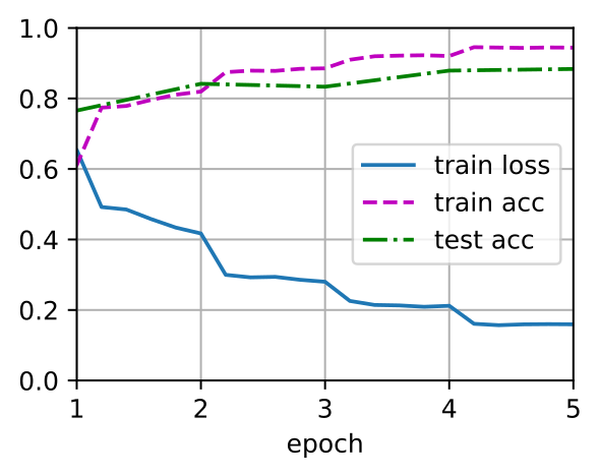

In [7]:
# 创建一个加入位置编码的PyPTO版textCNN实例（输出通道数需为8的倍数）
embed_size, kernel_sizes, nums_channels = 100, [3, 4, 5], [104, 104, 104]  # pypto.conv 要求输出通道数为 8 的倍数
devices = try_all_gpus()
net = PyPTOTextCNN_PE(len(vocab), embed_size, kernel_sizes, nums_channels)

def init_weights(m):
    if type(m) in (PyPTOLinear, PyPTOConv1d):
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights);

# 加载预训练词向量
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.requires_grad = False

# 训练和评估模型（超参数与14.3.1基线一致：lr=0.001，5个epoch）
lr, num_epochs = 0.001, 5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)